In [1]:
import os
import random
import numpy as np
from PIL import Image, ImageDraw
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import functional as F_transforms
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

/opt/conda/envs/pytorch/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_dir = "Data/IAH/"
positive_dir = os.path.join(data_dir, "A/")  # 正样本路径
negative_dir = os.path.join(data_dir, "None/")  # 负样本路径
mask_dir = os.path.join(data_dir, "masks/")  # Mask 路径
split_file = "train_val_split.txt"
image_size = 304
batch_size = 4
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")

In [3]:
# 读取 train_val_split 文件
def read_split_file(split_file):
    with open(split_file, "r", encoding="utf-8") as file:
        lines = file.readlines()
    train_files, val_files = [], []
    mode = None
    for line in lines:
        line = line.strip()
        if line.startswith("Train:"):
            mode = "train"
        elif line.startswith("Val:"):
            mode = "val"
        elif line:
            if mode == "train":
                train_files.append(line.replace("\\", "/"))
            elif mode == "val":
                val_files.append(line.replace("\\", "/"))
    return train_files, val_files

train_files, val_files = read_split_file(split_file)

In [4]:
# 检查路径是否存在
print("Checking all paths in train_files...")
for img_path in train_files:
    assert os.path.exists(img_path), f"File not found: {img_path}"

print("Checking all paths in val_files...")
for img_path in val_files:
    assert os.path.exists(img_path), f"File not found: {img_path}"

Checking all paths in train_files...
Checking all paths in val_files...


In [5]:
class HematDataset(Dataset):
    def __init__(self, image_paths, mask_dir, transform=None, target_size=(304, 304)):
        self.image_paths = image_paths
        self.mask_dir = mask_dir
        self.transform = transform
        self.target_size = target_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img_basename = os.path.basename(img_path)

        # 检查是否为负样本
        is_negative = "None" in img_path  # 判断是否是 None 文件夹下的图片

        if is_negative:
            # 自动生成全黑掩码
            mask = Image.new("L", self.target_size, 0)  # 全黑掩码
        else:
            # 正样本需要加载对应的掩码
            mask_path = os.path.join(self.mask_dir, img_basename.replace(".bmp", "_mask.bmp"))
            if not os.path.exists(mask_path):
                raise FileNotFoundError(f"Mask file not found: {mask_path}")

            with open(mask_path, "rb") as f:
                mask = Image.open(f).convert("L")

        # 加载图片
        with open(img_path, "rb") as f:
            image = Image.open(f).convert("RGB")

        # 调整图片和掩码大小
        image = image.resize(self.target_size, Image.BILINEAR)
        mask = mask.resize(self.target_size, Image.NEAREST)

        # 转换为张量
        if self.transform:
            image = self.transform(image)
        mask = F_transforms.to_tensor(mask).float()

        return image, mask


In [6]:
# 数据增强与变换
data_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

In [7]:
# 初始化数据集和数据加载器
train_dataset = HematDataset(train_files, mask_dir, transform=data_transforms, target_size=(image_size, image_size))
val_dataset = HematDataset(val_files, mask_dir, transform=data_transforms, target_size=(image_size, image_size))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)




In [8]:
# 检查数据加载器
for images, masks in train_loader:
    print(f"Image batch shape: {images.shape}")
    print(f"Mask batch shape: {masks.shape}")
    break

Image batch shape: torch.Size([4, 3, 304, 304])
Mask batch shape: torch.Size([4, 1, 304, 304])


In [9]:
# %%
class ConvBlock(nn.Module):
    """
    基本的卷积块：Conv -> BN -> ReLU -> Conv -> BN -> ReLU
    """
    def __init__(self, in_channels, out_channels):
        super(ConvBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    
    def forward(self, x):
        return self.conv(x)

class UpBlock(nn.Module):
    """
    上采样块：上采样 -> 拼接 -> 卷积块
    """
    def __init__(self, in_channels, skip_channels, out_channels):
        super(UpBlock, self).__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = ConvBlock(out_channels + skip_channels, out_channels)
    
    def forward(self, x, skip):
        x = self.up(x)
        # 如果上采样后尺寸不匹配，进行裁剪
        if x.size() != skip.size():
            x = F.interpolate(x, size=skip.size()[2:], mode='bilinear', align_corners=True)
        x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        return x

class NestedUNetPlusPlus(nn.Module):
    """
    UNet++ 模型实现
    """
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512, 1024]):
        super(NestedUNetPlusPlus, self).__init__()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU(inplace=True)
        
        # 编码器
        self.encoder1 = ConvBlock(in_channels, features[0])
        self.encoder2 = ConvBlock(features[0], features[1])
        self.encoder3 = ConvBlock(features[1], features[2])
        self.encoder4 = ConvBlock(features[2], features[3])
        self.encoder5 = ConvBlock(features[3], features[4])
        
        # 解码器
        self.up4_0 = UpBlock(features[4], features[3], features[3])  # e5 -> e4
        self.up3_0 = UpBlock(features[3], features[2], features[2])  # d4_0 -> e3
        self.up2_0 = UpBlock(features[2], features[1], features[1])  # d3_0 -> e2
        self.up1_0 = UpBlock(features[1], features[0], features[0])  # d2_0 -> e1
        
        self.up3_1 = UpBlock(features[3], features[2], features[2])  # d4_0 -> e3
        self.up2_1 = UpBlock(features[2], features[1], features[1])  # d3_1 -> e2
        self.up1_1 = UpBlock(features[1], features[0], features[0])  # d2_1 -> e1
        
        self.up2_2 = UpBlock(features[2], features[1], features[1])  # d3_1 -> e2
        self.up1_2 = UpBlock(features[1], features[0], features[0])  # d2_2 -> e1
        
        self.up1_3 = UpBlock(features[1], features[0], features[0])  # d2_2 -> e1
        
        # 输出层
        self.final = nn.Conv2d(features[0], out_channels, kernel_size=1)
        
    def forward(self, x):
        # 编码器
        e1 = self.encoder1(x)  # [B, 64, H, W]
        e2 = self.encoder2(self.pool(e1))  # [B, 128, H/2, W/2]
        e3 = self.encoder3(self.pool(e2))  # [B, 256, H/4, W/4]
        e4 = self.encoder4(self.pool(e3))  # [B, 512, H/8, W/8]
        e5 = self.encoder5(self.pool(e4))  # [B, 1024, H/16, W/16]
        
        # 解码器第一层
        d4_0 = self.up4_0(e5, e4)  # [B, 512, H/8, W/8]
        d3_0 = self.up3_0(d4_0, e3)  # [B, 256, H/4, W/4]
        d2_0 = self.up2_0(d3_0, e2)  # [B, 128, H/2, W/2]
        d1_0 = self.up1_0(d2_0, e1)  # [B, 64, H, W]
        
        # 解码器第二层
        d3_1 = self.up3_1(d4_0, e3)  # [B, 256, H/4, W/4]
        d2_1 = self.up2_1(d3_1, e2)  # [B, 128, H/2, W/2]
        d1_1 = self.up1_1(d2_1, e1)  # [B, 64, H, W]
        
        # 解码器第三层
        d2_2 = self.up2_2(d3_1, e2)  # [B, 128, H/2, W/2]
        d1_2 = self.up1_2(d2_2, e1)  # [B, 64, H, W]
        
        # 解码器第四层
        d1_3 = self.up1_3(d2_2, e1)  # [B, 64, H, W]
        
        # 聚合多个解码器输出，这里仅输出最后一个
        out = self.final(d1_3)
        out = torch.sigmoid(out)  # 对于二分类分割，使用 Sigmoid 激活函数
        return out

# 将类名与实例化代码保持一致
UNetplusplus = NestedUNetPlusPlus


In [10]:
# 定义 Dice 和 IoU 指标
def dice_coefficient(pred, target, epsilon=1e-6):
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    dice = (2. * intersection + epsilon) / (pred.sum() + target.sum() + epsilon)
    return dice

def iou_score(pred, target, epsilon=1e-6):
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    iou = (intersection + epsilon) / (union + epsilon)
    return iou

In [11]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5, save_dir='results_Unet++'):
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    
    # 用于记录每个epoch的指标
    train_losses = []
    val_losses = []
    train_dices = []
    val_dices = []
    train_ious = []
    val_ious = []

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        train_dice = 0.0
        train_iou = 0.0

        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            
            # 计算 Dice 和 IoU
            preds = (outputs > 0.5).float()
            train_dice += dice_coefficient(preds, masks).item() * images.size(0)
            train_iou += iou_score(preds, masks).item() * images.size(0)

        train_loss /= len(train_loader.dataset)
        train_dice /= len(train_loader.dataset)
        train_iou /= len(train_loader.dataset)

        train_losses.append(train_loss)
        train_dices.append(train_dice)
        train_ious.append(train_iou)

        # 验证阶段
        model.eval()
        val_loss = 0.0
        val_dice = 0.0
        val_iou = 0.0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item() * images.size(0)
                
                # 计算 Dice 和 IoU
                preds = (outputs > 0.5).float()
                val_dice += dice_coefficient(preds, masks).item() * images.size(0)
                val_iou += iou_score(preds, masks).item() * images.size(0)

        val_loss /= len(val_loader.dataset)
        val_dice /= len(val_loader.dataset)
        val_iou /= len(val_loader.dataset)

        val_losses.append(val_loss)
        val_dices.append(val_dice)
        val_ious.append(val_iou)

        print(f"Epoch {epoch + 1}/{num_epochs}, "
              f"Train Loss: {train_loss:.4f}, Train Dice: {train_dice:.4f}, Train IoU: {train_iou:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Dice: {val_dice:.4f}, Val IoU: {val_iou:.4f}")

    # 绘制并保存 Loss, Dice, IoU 曲线
    epochs = range(1, num_epochs + 1)
    plt.figure(figsize=(15, 5))

    # Loss 曲线
    plt.subplot(1, 3, 1)
    plt.plot(epochs, train_losses, 'b-', label='Train Loss')
    plt.plot(epochs, val_losses, 'r-', label='Val Loss')
    plt.title('Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Dice 曲线
    plt.subplot(1, 3, 2)
    plt.plot(epochs, train_dices, 'b-', label='Train Dice')
    plt.plot(epochs, val_dices, 'r-', label='Val Dice')
    plt.title('Dice Coefficient Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Dice Coefficient')
    plt.legend()

    # IoU 曲线
    plt.subplot(1, 3, 3)
    plt.plot(epochs, train_ious, 'b-', label='Train IoU')
    plt.plot(epochs, val_ious, 'r-', label='Val IoU')
    plt.title('IoU Curve')
    plt.xlabel('Epoch')
    plt.ylabel('IoU')
    plt.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'training_curves.png'))
    plt.show()

    # 保存模型
    model_path = os.path.join(save_dir, 'unetplusplus.pth')
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")

    return train_losses, val_losses, train_dices, val_dices, train_ious, val_ious


In [12]:
model = UNetplusplus().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

In [13]:
# %%
test_x = torch.randn(4, 3, 128, 128).to(device)  # 模拟 4 张 128x128 的输入图片
test_y = model(test_x)
print(f"Test Input shape: {test_x.shape}")
print(f"Test Output shape: {test_y.shape}")  # 期望: [4, 1, 128, 128]


Test Input shape: torch.Size([4, 3, 128, 128])
Test Output shape: torch.Size([4, 1, 128, 128])


Epoch 1/200, Train Loss: 0.2547, Train Dice: 0.0241, Train IoU: 0.0224, Val Loss: 0.1645, Val Dice: 0.0204, Val IoU: 0.0204
Epoch 2/200, Train Loss: 0.1277, Train Dice: 0.0638, Train IoU: 0.0492, Val Loss: 0.1210, Val Dice: 0.2646, Val IoU: 0.1656
Epoch 3/200, Train Loss: 0.0910, Train Dice: 0.1638, Train IoU: 0.1025, Val Loss: 0.1514, Val Dice: 0.2729, Val IoU: 0.1651
Epoch 4/200, Train Loss: 0.0725, Train Dice: 0.2851, Train IoU: 0.1867, Val Loss: 0.1263, Val Dice: 0.3015, Val IoU: 0.1861
Epoch 5/200, Train Loss: 0.0644, Train Dice: 0.2947, Train IoU: 0.1965, Val Loss: 0.0821, Val Dice: 0.0669, Val IoU: 0.0452
Epoch 6/200, Train Loss: 0.0620, Train Dice: 0.3388, Train IoU: 0.2293, Val Loss: 0.1118, Val Dice: 0.3662, Val IoU: 0.2346
Epoch 7/200, Train Loss: 0.0594, Train Dice: 0.3180, Train IoU: 0.2099, Val Loss: 0.0580, Val Dice: 0.4668, Val IoU: 0.3330
Epoch 8/200, Train Loss: 0.0505, Train Dice: 0.4905, Train IoU: 0.3472, Val Loss: 0.0883, Val Dice: 0.0204, Val IoU: 0.0204
Epoch 9/

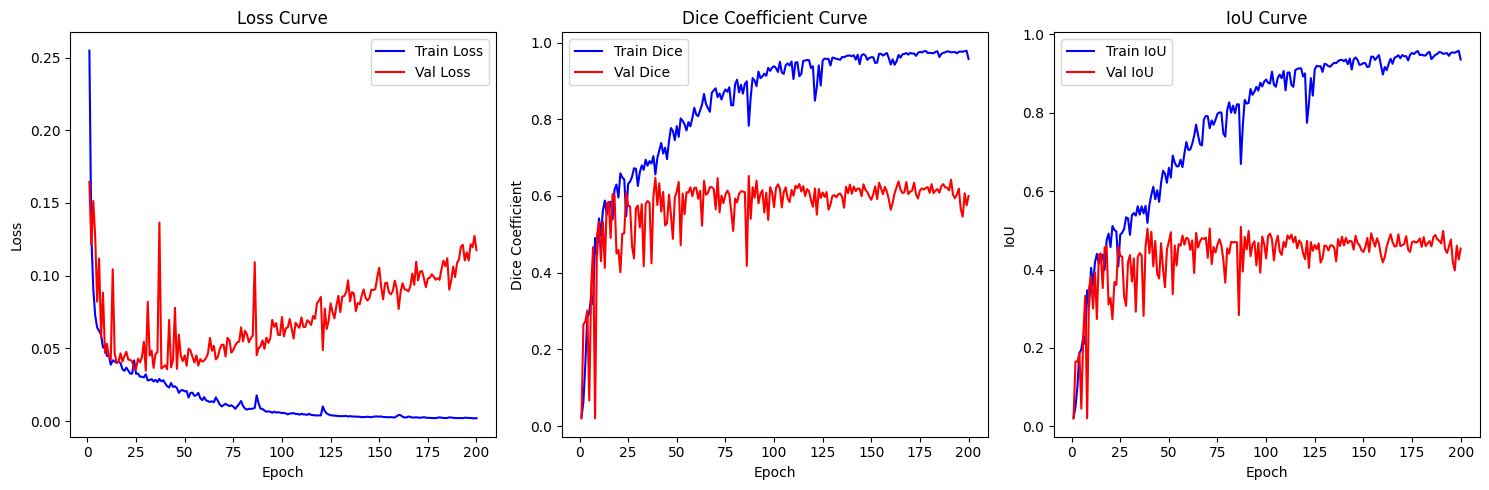

Model saved to results_Unet++/unetplusplus.pth


In [14]:
# 训练模型并记录指标
train_losses, val_losses, train_dices, val_dices, train_ious, val_ious = train_model(
    model, train_loader, val_loader, criterion, optimizer, num_epochs=200, save_dir='results_Unet++'
)


In [15]:
class HematDataset(Dataset): 
    def __init__(self, image_paths, mask_dir, transform=None, target_size=(304, 304)):
        self.image_paths = image_paths
        self.mask_dir = mask_dir
        self.transform = transform
        self.target_size = target_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img_basename = os.path.basename(img_path)

        # 检查是否为负样本
        is_negative = "None" in img_path  # 判断是否是 None 文件夹下的图片

        if is_negative:
            # 自动生成全黑掩码
            mask = Image.new("L", self.target_size, 0)  # 全黑掩码
        else:
            # 正样本需要加载对应的掩码
            mask_path = os.path.join(self.mask_dir, img_basename.replace(".bmp", "_mask.bmp"))
            if not os.path.exists(mask_path):
                raise FileNotFoundError(f"Mask file not found: {mask_path}")

            with open(mask_path, "rb") as f:
                mask = Image.open(f).convert("L")

        # 加载图片
        with open(img_path, "rb") as f:
            image = Image.open(f).convert("RGB")

        # 调整图片和掩码大小
        image = image.resize(self.target_size, Image.BILINEAR)
        mask = mask.resize(self.target_size, Image.NEAREST)

        # 转换为张量
        if self.transform:
            image = self.transform(image)
        mask = F_transforms.to_tensor(mask).float()

        return image, mask, img_basename  # 返回图像名称


In [16]:
def visualize_predictions(model, dataloader, save_dir='inference_results', device='cpu', image_paths=None):
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    model.eval()
    with torch.no_grad():
        for idx, (images, masks) in enumerate(dataloader):  # 不解包图像名称
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            preds = (outputs > 0.5).float()

            for i in range(images.size(0)):
                img = images[i].cpu()
                mask = masks[i].cpu().squeeze(0).numpy()
                pred = preds[i].cpu().squeeze(0).numpy()
                original_img = transforms.ToPILImage()(img)

                # 获取图像名称
                if image_paths:
                    img_name = os.path.basename(image_paths[idx * dataloader.batch_size + i])
                else:
                    img_name = f"image_{idx * dataloader.batch_size + i}.png"

                # 真实掩码
                true_mask = Image.fromarray((mask * 255).astype(np.uint8)).convert("L")

                # 预测掩码
                pred_mask = Image.fromarray((pred * 255).astype(np.uint8)).convert("L")

                # 在原图上标注预测掩码区域
                overlay = original_img.convert("RGBA")
                overlay_data = overlay.load()
                pred_mask_data = pred_mask.load()
                for y in range(pred_mask.height):
                    for x in range(pred_mask.width):
                        if pred_mask_data[x, y] > 128:
                            overlay_data[x, y] = (255, 0, 0, 150)  # 半透明红色

                # 创建组合图像
                combined = Image.new('RGB', (original_img.width * 4, original_img.height))
                combined.paste(original_img.convert("RGB"), (0, 0))
                combined.paste(true_mask.convert("RGB"), (original_img.width, 0))
                combined.paste(pred_mask.convert("RGB"), (original_img.width * 2, 0))
                combined.paste(overlay.convert("RGB"), (original_img.width * 3, 0))

                # 添加标题
                title_height = 30
                combined_with_title = Image.new('RGB', (combined.width, combined.height + title_height), (255, 255, 255))
                combined_with_title.paste(combined, (0, title_height))
                draw = ImageDraw.Draw(combined_with_title)
                draw.text((10, 5), "Original | True Mask | Predicted Mask | Overlay", fill=(0, 0, 0))

                # 使用图像名称保存，附加 'test'
                save_name = f"{os.path.splitext(img_name)[0]}_test.png"
                combined_with_title.save(os.path.join(save_dir, save_name))

    print(f"Inference results saved to {save_dir}")


In [17]:
# 运行推理与可视化
# 加载保存的模型Notebooks\results_denseUnet\denseunet.pth
model_path = os.path.join('results_Unet++', 'unetplusplus.pth')
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)

NestedUNetPlusPlus(
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU(inplace=True)
  (encoder1): ConvBlock(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (encoder2): ConvBlock(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(128, eps=1e-0

In [18]:
# 创建验证集的DataLoader，不进行shuffle
val_loader_inference = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=0)

# 进行推理并保存结果
visualize_predictions(model, val_loader_inference, save_dir='inference_results_unetplus', device=device)


Inference results saved to inference_results_unetplus
